Optimal RBFS Path: Andheri Bhim Nagar -> Andheri East -> NH-48 -> Jogeshwari -> Goregaon East (8 km)


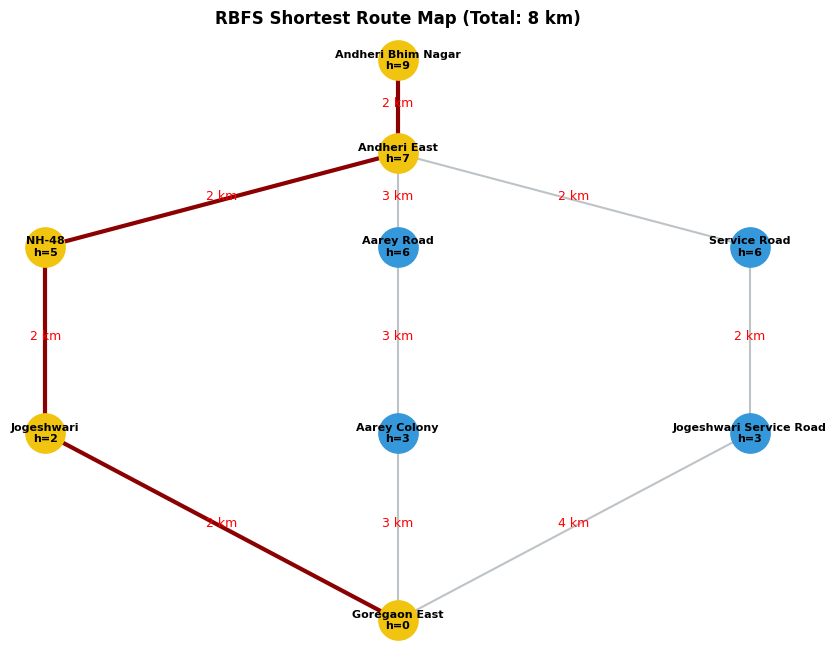

In [8]:
import matplotlib.pyplot as plt

# 1. NETWORK DEFINITION

graph = {

    'Andheri Bhim Nagar': {
        'Andheri East': 2
    },

    'Andheri East': {
        'NH-48': 2,
        'Aarey Road': 3,
        'Service Road': 2
    },

    # Route 1 (Fastest)
    'NH-48': {
        'Jogeshwari': 2
    },

    # Route 2
    'Aarey Road': {
        'Aarey Colony': 3
    },

    'Aarey Colony': {
        'Goregaon East': 3
    },

    # Route 3
    'Service Road': {
        'Jogeshwari Service Road': 2
    },

    'Jogeshwari': {
        'Goregaon East': 2
    },

    'Jogeshwari Service Road': {
        'Goregaon East': 4
    },

    'Goregaon East': {}
}

# Straight-line Heuristics h(n)

heuristics = {

    'Andheri Bhim Nagar': 9,
    'Andheri East': 7,
    'NH-48': 5,
    'Aarey Road': 6,
    'Aarey Colony': 3,
    'Service Road': 6,
    'Jogeshwari': 2,
    'Jogeshwari Service Road': 3,
    'Goregaon East': 0
}

coords = {

    'Andheri Bhim Nagar': (3,7),
    'Andheri East': (3,6),

    'NH-48': (1,5),
    'Aarey Road': (3,5),
    'Service Road': (5,5),

    'Jogeshwari': (1,3),
    'Aarey Colony': (3,3),
    'Jogeshwari Service Road': (5,3),

    'Goregaon East': (3,1)
}

# 2. RECURSIVE BEST-FIRST SEARCH (RBFS)

def rbfs_search(start, goal):

    success, path, cost, _ = rbfs(
        start,
        goal,
        g=0,
        f_limit=float('inf'),
        path=[start]
    )

    return path, cost


def rbfs(node, goal, g, f_limit, path):

    if node == goal:
        return True, path, g, g

    neighbors = graph[node]

    if not neighbors:
        return False, [], 0, float('inf')

    successors = []

    for neighbor, distance in neighbors.items():

        if neighbor not in path:

            next_g = g + distance

            next_f = max(
                next_g + heuristics[neighbor],
                g + heuristics[node]
            )

            successors.append(
                [next_f, neighbor, next_g]
            )

    if not successors:
        return False, [], 0, float('inf')

    while True:

        successors.sort(key=lambda x: x[0])

        best = successors[0]

        if best[0] > f_limit:
            return False, [], 0, best[0]

        alternative_f = (
            successors[1][0]
            if len(successors) > 1
            else float('inf')
        )

        success, result_path, total_g, returned_f = rbfs(
            best[1],
            goal,
            best[2],
            min(f_limit, alternative_f),
            path + [best[1]]
        )

        best[0] = returned_f

        if success:
            return True, result_path, total_g, returned_f


path, total_dist = rbfs_search(
    'Andheri Bhim Nagar',
    'Goregaon East'
)

print(f"Optimal RBFS Path: {' -> '.join(path)} ({total_dist} km)")

# 3. GRAPH PLOTTING

plt.figure(figsize=(10,8))

for node, neighbors in graph.items():

    x1, y1 = coords[node]

    for neighbor, dist in neighbors.items():

        x2, y2 = coords[neighbor]

        is_path = (
            node in path and
            neighbor in path and
            path.index(neighbor) == path.index(node) + 1
        )

        color, width = (
            ('darkred',3)
            if is_path
            else ('#bdc3c7',1.5)
        )

        plt.plot(
            [x1,x2],
            [y1,y2],
            color=color,
            linewidth=width,
            zorder=1
        )

        plt.text(
            (x1+x2)/2,
            (y1+y2)/2,
            f"{dist} km",
            color='red',
            fontsize=9,
            ha='center'
        )

# Draw Nodes

for node,(x,y) in coords.items():

    color = (
        '#f1c40f'
        if node in path
        else '#3498db'
    )

    plt.scatter(
        x,
        y,
        color=color,
        s=800,
        zorder=2
    )

    plt.text(
        x,
        y,
        f"{node}\nh={heuristics[node]}",
        ha='center',
        va='center',
        color='black',
        fontsize=8,
        fontweight='bold'
    )

plt.title(
    f"RBFS Shortest Route Map (Total: {total_dist} km)",
    fontsize=12,
    fontweight='bold'
)

plt.axis('off')
plt.show()